In [2]:
import torch
import torchvision.transforms as T
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter

from models import DLV3Reg

/home/kafkaon1/miniconda3/envs/mlenv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
img_path = './example.png' #400_10.png   450_478
im = T.ToTensor()(Image.open(img_path)).unsqueeze(0)

In [4]:
model = DLV3Reg()
model.load_state_dict(torch.load('roof_extractor.pth'))

<All keys matched successfully>

In [5]:
model.to('cuda:0')
model.eval()
print('.')

.


In [6]:
outta, polys = model.predict(im.to('cuda:0'))

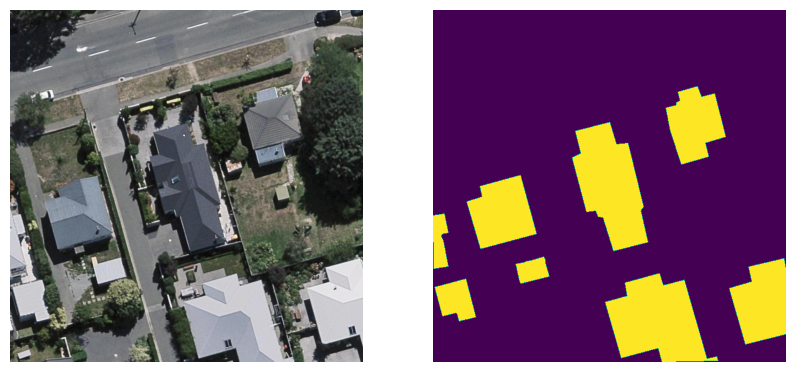

In [9]:
fix, ax = plt.subplots(1,2, figsize=(10, 5))
ax[0].imshow(im[0].permute(1,2,0).detach().cpu().numpy())
ax[1].imshow(outta[0,0, :, :].detach().cpu().numpy())
# turn off axes
for a in ax:
    a.axis('off')
fix.savefig('example_out.png')